1: Импорт библиотек (Code)

In [24]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube

# Настройка устройства (GPU, если доступно, иначе CPU или MPS для Mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Используемое устройство: {device}")

# Зафиксируем сиды для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

Используемое устройство: cpu


In [25]:
def to_tensor(arr, requires_grad=False):
    tensor = torch.tensor(arr, dtype=torch.float32).to(device)
    tensor.requires_grad = requires_grad
    return tensor

In [ ]:
# --- 1. Физические параметры и геометрия ---
T_max = 1.0
L = 1.0
y_chip_top = 0.2    # Граница Чип / Радиатор
y_sink_top = 0.6    # Граница Радиатор / Воздух

# Свойства материалов
D1, k1 = 0.05, 10.0   # Chip
D2, k2 = 0.08, 5.0    # Heat Sink
D3, k3 = 0.10, 0.1    # Ambient
h1, h2 = 50.0, 20.0     # Коэффициенты теплопередачи

T_ambient = 20.0
T_0 = 20.0

N_ic = 1200
N_bc = 2000
N_col = 5000  
N_int = 1000  

# --- 2. Вспомогательные функции ---
def generate_domain_points(y_min, y_max, n_points):
    x = np.random.uniform(0, L, (n_points, 1))
    y = np.random.uniform(y_min, y_max, (n_points, 1))
    t = np.random.uniform(0, T_max, (n_points, 1))
    return to_tensor(x, True), to_tensor(y, True), to_tensor(t, True)

def generate_interface_points(y_val, n_points):
    x = np.random.uniform(0, L, (n_points, 1))
    y = np.full((n_points, 1), y_val)
    t = np.random.uniform(0, T_max, (n_points, 1))
    return to_tensor(x, True), to_tensor(y, True), to_tensor(t, True)

# --- 3. Генерация точек внутри доменов и на интерфейсах ---
x1, y1, t1 = generate_domain_points(0.0, y_chip_top, N_col)
x2, y2, t2 = generate_domain_points(y_chip_top, y_sink_top, N_col)
x3, y3, t3 = generate_domain_points(y_sink_top, L, N_col)

x_int1, y_int1, t_int1 = generate_interface_points(y_chip_top, N_int)
x_int2, y_int2, t_int2 = generate_interface_points(y_sink_top, N_int)

# --- 4. Начальные условия (IC, t=0) ---
# Генерируем общий массив и распределяем по слоям с исправлением формы
x_ic_raw = np.random.uniform(0, L, (N_ic, 1))
y_ic_raw = np.random.uniform(0, L, (N_ic, 1))

# IC для Чипа
mask_ic_1 = (y_ic_raw <= y_chip_top).flatten()
x_ic_chip = to_tensor(x_ic_raw[mask_ic_1]).view(-1, 1)
y_ic_chip = to_tensor(y_ic_raw[mask_ic_1]).view(-1, 1)
t_ic_chip = to_tensor(np.zeros((len(x_ic_chip), 1)))

# IC для Радиатора
mask_ic_2 = ((y_ic_raw > y_chip_top) & (y_ic_raw <= y_sink_top)).flatten()
x_ic_sink = to_tensor(x_ic_raw[mask_ic_2]).view(-1, 1)
y_ic_sink = to_tensor(y_ic_raw[mask_ic_2]).view(-1, 1)
t_ic_sink = to_tensor(np.zeros((len(x_ic_sink), 1)))

# IC для Воздуха
mask_ic_3 = (y_ic_raw > y_sink_top).flatten()
x_ic_ambient = to_tensor(x_ic_raw[mask_ic_3]).view(-1, 1)
y_ic_ambient = to_tensor(y_ic_raw[mask_ic_3]).view(-1, 1)
t_ic_ambient = to_tensor(np.zeros((len(x_ic_ambient), 1)))

# --- 5. Граничные условия (BC, края пластины) ---
N_edge = N_bc // 4
t_bc_all = np.random.uniform(0, T_max, (N_bc, 1))
pts_rand = np.random.uniform(0, L, (N_bc, 1))

x_bc_raw = np.zeros((N_bc, 1))
y_bc_raw = np.zeros((N_bc, 1))

# Распределяем точки по сторонам квадрата
x_bc_raw[0:N_edge] = pts_rand[0:N_edge]; y_bc_raw[0:N_edge] = 0.0           # Bottom
x_bc_raw[N_edge:2*N_edge] = pts_rand[N_edge:2*N_edge]; y_bc_raw[N_edge:2*N_edge] = L # Top
x_bc_raw[2*N_edge:3*N_edge] = 0.0; y_bc_raw[2*N_edge:3*N_edge] = pts_rand[2*N_edge:3*N_edge] # Left
x_bc_raw[3*N_edge:] = L; y_bc_raw[3*N_edge:] = pts_rand[3*N_edge:]         # Right

x_bc_full = to_tensor(x_bc_raw)
y_bc_full = to_tensor(y_bc_raw)
t_bc_full = to_tensor(t_bc_all)

# Распределяем BC по моделям с исправлением формы (.view(-1, 1))
# Модель Чипа (низ и нижние бока)
mask_bc_1 = (y_bc_raw <= y_chip_top).flatten()
x_bc_chip = x_bc_full[mask_bc_1].view(-1, 1)
y_bc_chip = y_bc_full[mask_bc_1].view(-1, 1)
t_bc_chip = t_bc_full[mask_bc_1].view(-1, 1)
u_bc_chip = torch.zeros_like(x_bc_chip)

# Модель Радиатора (средние бока)
mask_bc_2 = ((y_bc_raw > y_chip_top) & (y_bc_raw <= y_sink_top)).flatten()
x_bc_sink = x_bc_full[mask_bc_2].view(-1, 1)
y_bc_sink = y_bc_full[mask_bc_2].view(-1, 1)
t_bc_sink = t_bc_full[mask_bc_2].view(-1, 1)
u_bc_sink = torch.zeros_like(x_bc_sink)

# Модель Воздуха (верх и верхние бока)
mask_bc_3 = (y_bc_raw > y_sink_top).flatten()
x_bc_ambient = x_bc_full[mask_bc_3].view(-1, 1)
y_bc_ambient = y_bc_full[mask_bc_3].view(-1, 1)
t_bc_ambient = t_bc_full[mask_bc_3].view(-1, 1)
u_bc_ambient = torch.zeros_like(x_bc_ambient)

print("Все данные успешно подготовлены.")
print(f"IC: Chip={len(x_ic_chip)}, Sink={len(x_ic_sink)}, Ambient={len(x_ic_ambient)}")
print(f"BC: Chip={len(x_bc_chip)}, Sink={len(x_bc_sink)}, Ambient={len(x_bc_ambient)}")

Все данные успешно подготовлены.
IC: Chip=232, Sink=463, Ambient=505
BC: Chip=688, Sink=402, Ambient=910


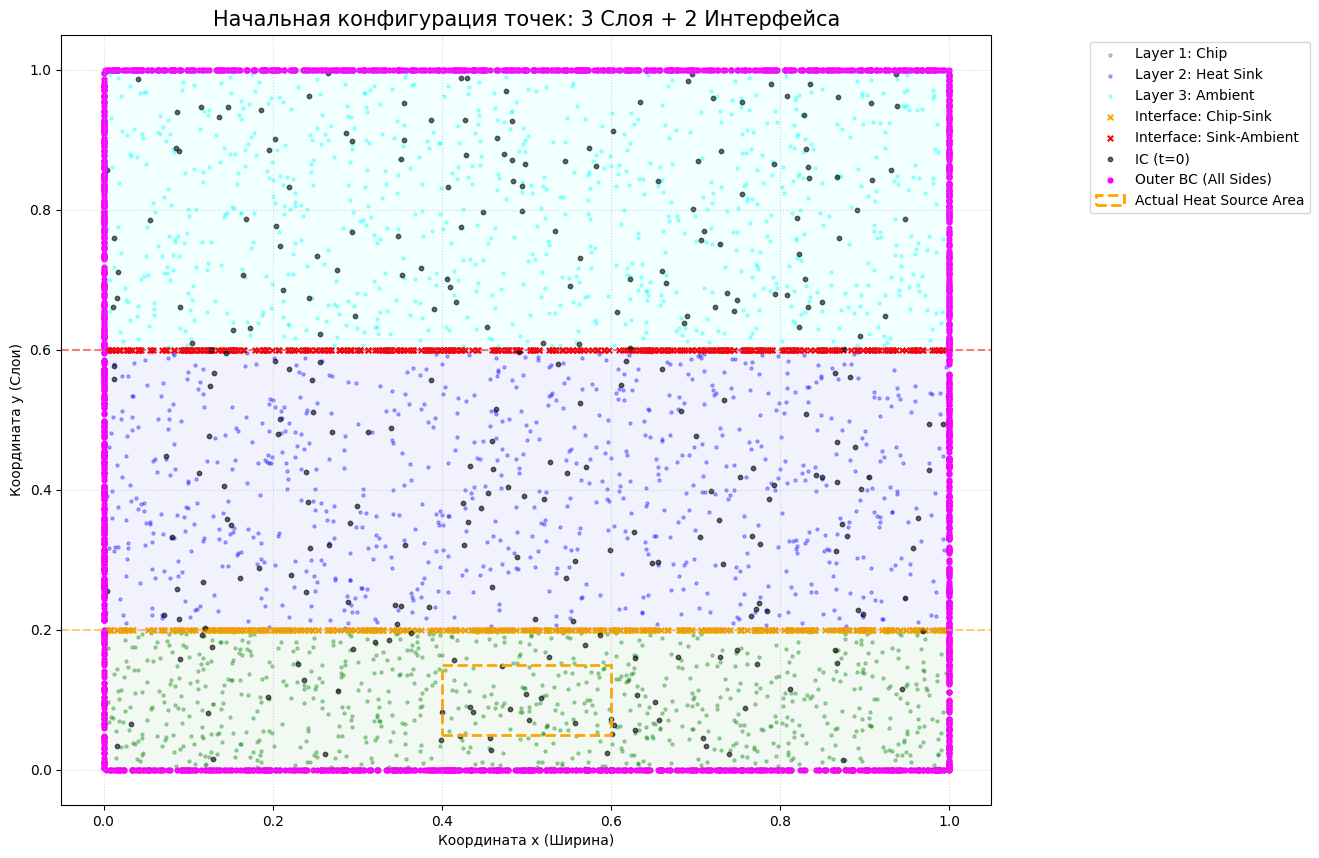

In [27]:
import matplotlib.patches as patches

# Переводим тензоры обратно в numpy для визуализации
def to_np(tensor):
    return tensor.detach().cpu().numpy()

plt.figure(figsize=(12, 10))
ax = plt.gca()

# 1. Точки коллокации (физика внутри слоев)
# Отображаем по 800 точек из каждого слоя для наглядности
plt.scatter(to_np(x1)[:800], to_np(y1)[:800], c='green', s=5, alpha=0.3, label='Layer 1: Chip')
plt.scatter(to_np(x2)[:800], to_np(y2)[:800], c='blue', s=5, alpha=0.3, label='Layer 2: Heat Sink')
plt.scatter(to_np(x3)[:800], to_np(y3)[:800], c='cyan', s=5, alpha=0.3, label='Layer 3: Ambient')

# 2. Точки ИНТЕРФЕЙСОВ (линии сшивки решений)
# Это ключевые точки, где нейросети "обмениваются" теплом
plt.scatter(to_np(x_int1)[:400], to_np(y_int1)[:400], c='orange', s=15, marker='x', label='Interface: Chip-Sink')
plt.scatter(to_np(x_int2)[:400], to_np(y_int2)[:400], c='red', s=15, marker='x', label='Interface: Sink-Ambient')

# 3. Начальные условия (IC, t=0)
plt.scatter(to_np(x_ic)[:300], to_np(y_ic)[:300], c='black', s=10, alpha=0.6, label='IC (t=0)')

# 4. Границы (BC, внешние края)
# Если вы используете x_bc_t и y_bc_t из предыдущего кода
plt.scatter(to_np(x_bc_t), to_np(y_bc_t), c='magenta', s=12, label='Outer BC (All Sides)')

# --- Декорации и разметка зон ---
# Добавляем полупрозрачные прямоугольники для визуального разделения
ax.add_patch(patches.Rectangle((0, 0), L, y_chip_top, color='green', alpha=0.05))
ax.add_patch(patches.Rectangle((0, y_chip_top), L, (y_sink_top - y_chip_top), color='blue', alpha=0.05))
ax.add_patch(patches.Rectangle((0, y_sink_top), L, (L - y_sink_top), color='cyan', alpha=0.05))

# Отрисовка области источника тепла (CPU Die)
chip_source = patches.Rectangle((0.4, 0.05), 0.2, 0.1, linewidth=2, 
                                edgecolor='orange', facecolor='none', 
                                linestyle='--', label='Actual Heat Source Area')
ax.add_patch(chip_source)

# Линии границ разделения слоев
plt.axhline(y_chip_top, color='orange', linestyle='--', alpha=0.5)
plt.axhline(y_sink_top, color='red', linestyle='--', alpha=0.5)

plt.title("Начальная конфигурация точек: 3 Слоя + 2 Интерфейса", fontsize=15)
plt.xlabel("Координата x (Ширина)")
plt.ylabel("Координата y (Слои)")
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.show()

In [43]:
import torch.nn.functional as F

class PINN(nn.Module):
    def __init__(self, num_hidden_layers=5, num_neurons=60):
        super(PINN, self).__init__()
        layers =[]
        layers.append(nn.Linear(3, num_neurons))
        layers.append(nn.Tanh())
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(num_neurons, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        # Softplus гарантирует, что температура не уйдет в минус
        return F.softplus(self.net(inputs))

# Инициализируем 3 разные модели!
model_chip = PINN().to(device)
model_sink = PINN().to(device)
model_ambient = PINN().to(device)

# Собираем параметры всех моделей для оптимизатора
all_params = list(model_chip.parameters()) + \
             list(model_sink.parameters()) + \
             list(model_ambient.parameters())

In [40]:
def get_source_term(x, y, t):
    intensity = 100.0 # Немного снизим для стабильности
    sigma = 0.1 
    # Центр теперь в (0.5, 0.1) — это середина ЧИПА
    chip_area = torch.exp(-((x - 0.5)**2 + (y - 0.1)**2) / (2 * sigma**2))
    return intensity * chip_area

In [ ]:
mse_loss = nn.MSELoss()

def compute_pde_loss(model, x, y, t, D, is_chip=False):
    u = model(x, y, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    
    # Считаем остаток уравнения
    f_pred = u_t - D * (u_xx + u_yy)
    
    # Если это чип, вычитаем источник тепла прямо из уравнения
    if is_chip:
        Q = get_source_term(x, y, t) / 100.0 # нормировка
        f_pred = f_pred - Q
        
    return mse_loss(f_pred, torch.zeros_like(f_pred))

def calculate_loss():
    # 1. PDE Loss для каждого материала
    loss_pde_chip = compute_pde_loss(model_chip, x1, y1, t1, D1, is_chip=True)
    # Источник тепла Q(t,x) добавляем только в Чип!
    
    loss_pde_sink = compute_pde_loss(model_sink, x2, y2, t2, D2)
    loss_pde_ambient = compute_pde_loss(model_ambient, x3, y3, t3, D3)
    
    loss_pde = loss_pde_chip + loss_pde_sink + loss_pde_ambient
    
    # 2. ИНТЕРФЕЙСНЫЙ ЛОСС (Сшивание решений)
    # -- Интерфейс 1: Chip <-> Sink --
    u1_i1 = model_chip(x_int1, y_int1, t_int1)
    u2_i1 = model_sink(x_int1, y_int1, t_int1)
    
    # НОВОЕ: Прямое равенство температур (сшивка по значениям)
    # Это заставит Радиатор принять температуру Чипа
    loss_cont1 = mse_loss(u1_i1, u2_i1) 
    
    # Потоки (как были)
    dy1_i1 = torch.autograd.grad(u1_i1, y_int1, torch.ones_like(u1_i1), create_graph=True)[0]
    dy2_i1 = torch.autograd.grad(u2_i1, y_int1, torch.ones_like(u2_i1), create_graph=True)[0]
    loss_flux1 = mse_loss(-k1 * dy1_i1, -k2 * dy2_i1)
    
    loss_int1 = 10.0 * loss_cont1 + loss_flux1 # Вес на непрерывность выше

    # -- Интерфейс 2: Sink <-> Ambient --
    u2_i2 = model_sink(x_int2, y_int2, t_int2)
    u3_i2 = model_ambient(x_int2, y_int2, t_int2)
    
    loss_cont2 = mse_loss(u2_i2, u3_i2) # Сшивка Радиатора и Воздуха
    
    dy2_i2 = torch.autograd.grad(u2_i2, y_int2, torch.ones_like(u2_i2), create_graph=True)[0]
    dy3_i2 = torch.autograd.grad(u3_i2, y_int2, torch.ones_like(u3_i2), create_graph=True)[0]
    loss_flux2 = mse_loss(-k2 * dy2_i2, -k3 * dy3_i2)
    
    loss_int2 = 10.0 * loss_cont2 + loss_flux2
    
    loss_interface = loss_int1 + loss_int2
    # 3. Начальные условия (IC) - каждая модель в своей зоне
    # u_target везде 0.0, так как T_0=20 мы приняли за ноль
    loss_ic = mse_loss(model_chip(x_ic_chip, y_ic_chip, t_ic_chip), torch.zeros_like(x_ic_chip)) + \
           mse_loss(model_sink(x_ic_sink, y_ic_sink, t_ic_sink), torch.zeros_like(x_ic_sink)) + \
           mse_loss(model_ambient(x_ic_ambient, y_ic_ambient, t_ic_ambient), torch.zeros_like(x_ic_ambient))

    # 4. Граничные условия (BC) - используем ваши распределенные точки
    loss_bc = mse_loss(model_chip(x_bc_chip, y_bc_chip, t_bc_chip), u_bc_chip) + \
           mse_loss(model_sink(x_bc_sink, y_bc_sink, t_bc_sink), u_bc_sink) + \
           mse_loss(model_ambient(x_bc_ambient, y_bc_ambient, t_bc_ambient), u_bc_ambient)
    
    # Итоговый Loss (IC и BC пока упрощаем для фокуса на интерфейсах)
    # В конце calculate_loss:
    w_pde = 500.0
    w_interface = 2000.0 # ОГРОМНЫЙ вес для сшивки!
    w_ic_bc = 1.0
    
    total_loss = w_pde * loss_pde + w_interface * (loss_int1 + loss_int2) + w_ic_bc * (loss_ic + loss_bc)
    
    return total_loss, loss_pde, loss_interface

=== Запуск оптимизатора Adam (3 модели) ===
Epoch    0 | Total Loss: 1.2131e+02 | PDE: 1.2821e-01 | Interface: 1.0799e-01 | Max T_pred: 0.7842
Epoch  500 | Total Loss: 4.2868e+01 | PDE: 8.3519e-02 | Interface: 4.3314e-04 | Max T_pred: 0.6289
Epoch 1000 | Total Loss: 1.6122e+01 | PDE: 1.6676e-02 | Interface: 1.4371e-02 | Max T_pred: 0.6886
Epoch 1500 | Total Loss: 8.0959e+00 | PDE: 8.0902e-03 | Interface: 7.5628e-03 | Max T_pred: 0.6243

=== Запуск оптимизатора L-BFGS (Сшивание решений) ===

Обучение завершено!
Final Total Loss: 1.6326e+00
Final Interface Mismatch: 1.5967e-04


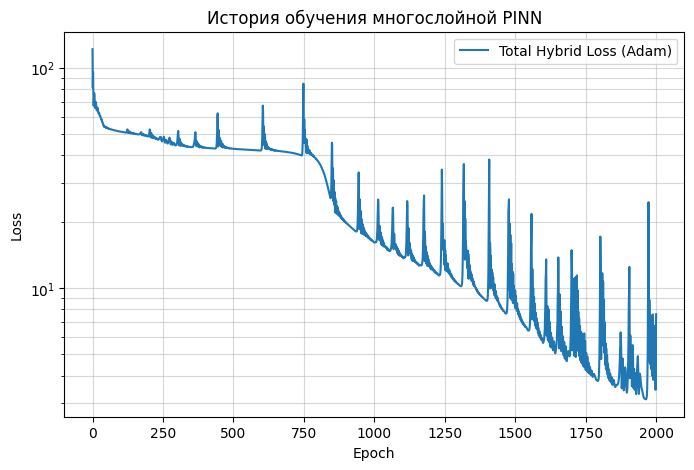

In [45]:
# --- Настройка обучения ---
# Список параметров всех трех сетей
all_params = list(model_chip.parameters()) + \
             list(model_sink.parameters()) + \
             list(model_ambient.parameters())

# Оптимизатор 1: Adam
optimizer_adam = torch.optim.Adam(all_params, lr=1e-3)

epochs_adam = 2000
loss_history = []

print("=== Запуск оптимизатора Adam (3 модели) ===")
for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()
    
    # calculate_loss теперь не требует аргументов, 
    # так как использует глобальные model_chip, model_sink, model_ambient
    total_loss, l_pde, l_int = calculate_loss() 
    
    total_loss.backward()
    optimizer_adam.step()
    
    loss_history.append(total_loss.item())
    
    if epoch % 500 == 0:
        with torch.no_grad():
            current_max = model_chip(x1, y1, t1).max().item()
        print(f"Epoch {epoch:4d} | Total Loss: {total_loss.item():.4e} | PDE: {l_pde.item():.4e} | Interface: {l_int.item():.4e} | Max T_pred: {current_max:.4f}")

# Оптимизатор 2: L-BFGS
print("\n=== Запуск оптимизатора L-BFGS (Сшивание решений) ===")
optimizer_lbfgs = torch.optim.LBFGS(
    all_params, # Передаем параметры ВСЕХ моделей
    lr=0.1, 
    max_iter=500, 
    history_size=50
)

def closure():
    optimizer_lbfgs.zero_grad()
    # L-BFGS требует только один тензор лосса для возврата
    t_loss, _, _ = calculate_loss()
    t_loss.backward()
    return t_loss

optimizer_lbfgs.step(closure)

# Финальная проверка
final_total, final_pde, final_int = calculate_loss()
print(f"\nОбучение завершено!")
print(f"Final Total Loss: {final_total.item():.4e}")
print(f"Final Interface Mismatch: {final_int.item():.4e}")

# График лосса
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Total Hybrid Loss (Adam)')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('История обучения многослойной PINN')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

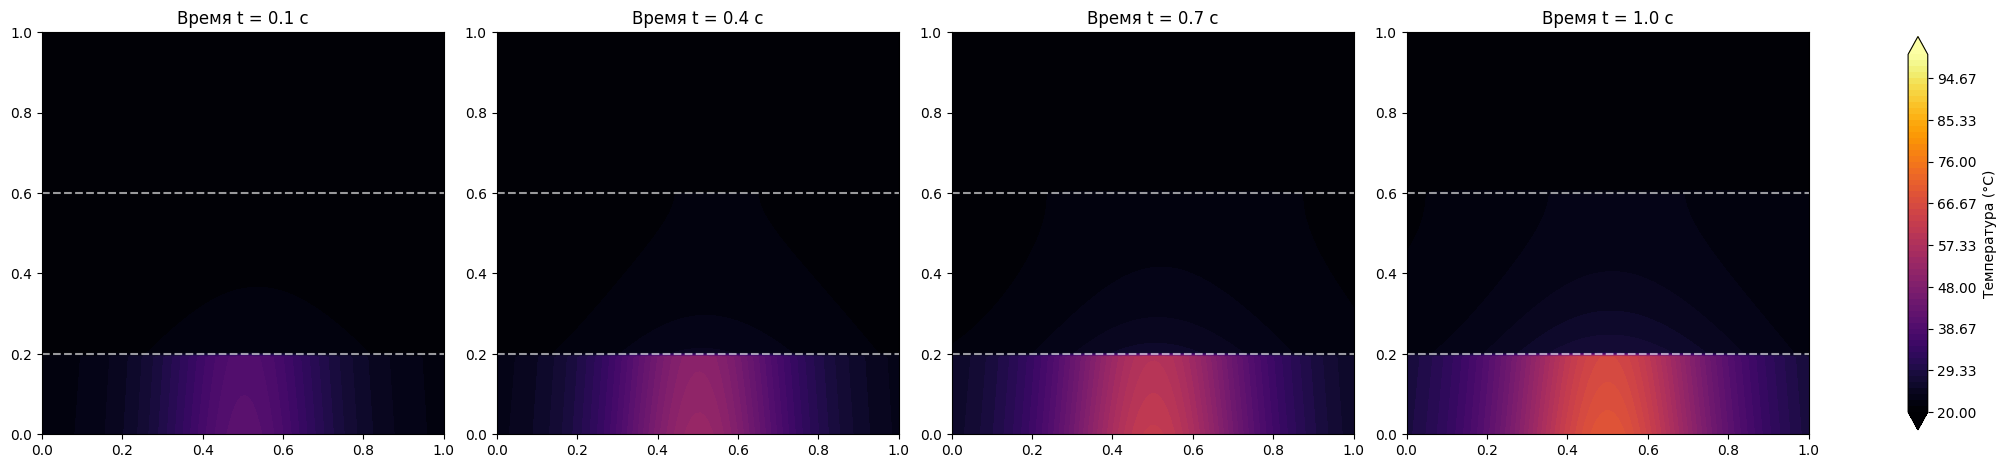

In [46]:

# --- Создание сетки для визуализации ---
nx, ny = 100, 100  # Разрешение картинки (100x100 пикселей)

# Создаем одномерные массивы координат
x_coords = np.linspace(0, L, nx)
y_coords = np.linspace(0, L, ny)

# Создаем 2D матрицы (сетку)
X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

# Вытягиваем их в длинные столбцы (flatten) для подачи в нейросеть
X_flat = X_mesh.reshape(-1, 1)
Y_flat = Y_mesh.reshape(-1, 1)
# Улучшенная визуализация для микропроцессорной модели
# --- ИСПРАВЛЕННАЯ визуализация ---
time_steps = [0.1, 0.4, 0.7, 1.0]
fig, axes = plt.subplots(1, len(time_steps), figsize=(20, 5), constrained_layout=True)

# Задаем фиксированные уровни от 20 до 100 градусов
# Это предотвратит ошибку, если данных пока нет (все значения 20)
custom_levels = np.linspace(20, 100, 61) 

for ax, t_val in zip(axes, time_steps):
    T_flat = np.full_like(X_flat, t_val)
    X_t = torch.tensor(X_flat, dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y_flat, dtype=torch.float32, device=device)
    T_t = torch.tensor(T_flat, dtype=torch.float32, device=device)

    U_pred = np.zeros_like(X_flat)
    
    with torch.no_grad():
        m1 = (Y_flat <= y_chip_top).flatten()
        m2 = ((Y_flat > y_chip_top) & (Y_flat <= y_sink_top)).flatten()
        m3 = (Y_flat > y_sink_top).flatten()
        
        # Предсказания трех моделей
        if m1.any(): U_pred[m1] = model_chip(X_t[m1], Y_t[m1], T_t[m1]).cpu().numpy()
        if m2.any(): U_pred[m2] = model_sink(X_t[m2], Y_t[m2], T_t[m2]).cpu().numpy()
        if m3.any(): U_pred[m3] = model_ambient(X_t[m3], Y_t[m3], T_t[m3]).cpu().numpy()
            
        U_final = U_pred.reshape(ny, nx) * 100.0 + 20.0 

    # Проверка: если данных нет, рисуем просто закрашенный фон
    if np.max(U_final) - np.min(U_final) < 1e-3:
        cf = ax.contourf(X_mesh, Y_mesh, U_final, levels=[19.9, 20.1], cmap="inferno")
    else:
        # Используем явно заданные уровни
        cf = ax.contourf(X_mesh, Y_mesh, U_final, levels=custom_levels, cmap="inferno", extend='both')
    
    ax.axhline(y_chip_top, color='white', linestyle='--', alpha=0.6)
    ax.axhline(y_sink_top, color='white', linestyle='--', alpha=0.6)
    ax.set_title(f"Время t = {t_val} c")
    ax.set_aspect('equal')

# Создаем один общий colorbar для всех графиков
cbar = fig.colorbar(cf, ax=axes, shrink=0.8)
cbar.set_label("Температура (°C)")
plt.show()